<a href="https://colab.research.google.com/github/MandelaDoondiUshasri/Long-Tail/blob/main/Imbalance_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import tensorflow as tf
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import get_file
print("Demo by M.D UshaSri,22a81a6136")

Demo by M.D UshaSri,22a81a6136


In [2]:

from google.colab import drive
drive.mount('/content/drive')
print("Demo by M.D UshaSri,22a81a6136")

Mounted at /content/drive
Demo by M.D UshaSri,22a81a6136


In [3]:



import os
import zipfile
#Download and save in google drive from
#URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
# Define the dataset path inside Google Drive
google_drive_path = "/content/drive/MyDrive/Imbalance/imbalance (2).zip"

# Define extraction path (where to extract the dataset)
extract_path = "/content/cats_and_dogs_filtered"

# Verify if the dataset exists
if not os.path.exists(google_drive_path):
    print("❌ Dataset file not found! Check the path in Google Drive.")
else:
    print("✅ Dataset found in Google Drive!")




✅ Dataset found in Google Drive!


In [4]:
# =========================
if not os.path.exists(extract_path):
    print("🔄 Extracting dataset... Please wait.")
    with zipfile.ZipFile(google_drive_path, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Dataset extracted successfully!")
else:
    print("📂 Dataset already extracted.")


train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'validation')

# Check if train and validation directories exist
if not os.path.exists(train_dir) or not os.path.exists(validation_dir):
    print("❌ Training or validation directories are missing!")
else:
    print("✅ Training and validation directories exist.")
    print("📂 Training folder contents:", os.listdir(train_dir))
    print("📂 Validation folder contents:", os.listdir(validation_dir))



🔄 Extracting dataset... Please wait.
✅ Dataset extracted successfully!
✅ Training and validation directories exist.
📂 Training folder contents: ['cats', 'dogs']
📂 Validation folder contents: ['cats', 'dogs']


M.D UshaSri,22a81a6136'Task-6 Dl Lab
✅ Image loaded successfully!
📏 Image Shape: (224, 300, 3)


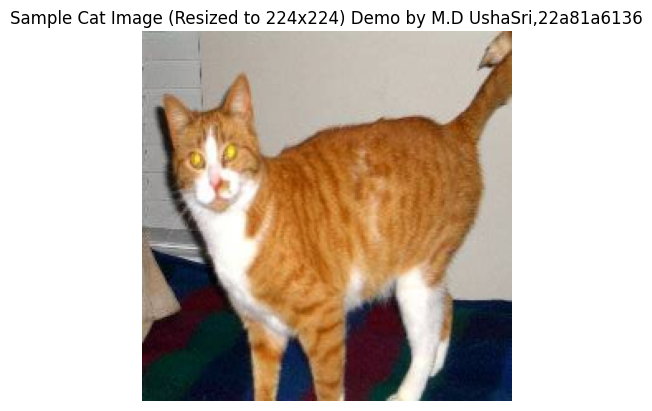

In [5]:

import cv2
import matplotlib.pyplot as plt

# Define a sample image path (change 'cats' to 'dogs' if needed)
sample_image_path = os.path.join(train_dir, 'cats', os.listdir(os.path.join(train_dir, 'cats'))[0])

# Load the image using OpenCV
img = cv2.imread(sample_image_path)
print("M.D UshaSri,22a81a6136'Task-6 Dl Lab")

# Check if the image is loaded correctly
if img is None:
    print("❌ Image not loaded! Check the file path.")
else:
    print("✅ Image loaded successfully!")
    print("📏 Image Shape:", img.shape)  # (Height, Width, Channels)

    # Convert BGR to RGB (OpenCV loads images in BGR format)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to match VGG-16 input size (224x224)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Display the image using Matplotlib (since cv2.imshow() does not work in Colab)
    plt.imshow(img_resized)
    plt.axis("off")  # Hide axes
    plt.title("Sample Cat Image (Resized to 224x224) Demo by M.D UshaSri,22a81a6136")
    plt.show()




In [6]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values (0-255 → 0-1)
    rotation_range=40,  # Rotate images randomly
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shearing transformation
    zoom_range=0.2,  # Zoom in/out
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill missing pixels after transformation
)

# Validation dataset: Only rescale (no augmentation)
validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to VGG-16 input size
    batch_size=16,
    class_mode='binary'  # Binary classification (cats vs dogs)
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)




Found 1250 images belonging to 2 classes.
Found 750 images belonging to 2 classes.


In [7]:
base_model = tf.keras.applications.ResNet50(weights='imagenet',include_top=False,input_shape=(224, 224, 3))
base_model.trainable = False
base_model.summary()

model = tf.keras.Sequential([
    base_model,  # Use VGG-16 as a feature extractor
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Dropout to reduce overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()




94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=100,
    verbose=1
)

test_loss, test_acc = model.evaluate(validation_generator)
print(f"\n✅ Model Test Accuracy: {test_acc * 100:.2f}%")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 403ms/step - accuracy: 0.7665 - loss: 0.6773 - val_accuracy: 0.6667 - val_loss: 0.8899
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.8068 - loss: 0.5234 - val_accuracy: 0.6667 - val_loss: 0.6283
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 235ms/step - accuracy: 0.7987 - loss: 0.5250 - val_accuracy: 0.6667 - val_loss: 0.7465
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.7984 - loss: 0.5154 - val_accuracy: 0.6667 - val_loss: 0.6529
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 239ms/step - accuracy: 0.7933 - loss: 0.5119 - val_accuracy: 0.6667 - val_loss: 0.6896
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.7973 - loss: 0.5110 - val_accuracy: 0.6667 - val_loss: 0.6776
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 277ms/step - accuracy: 0.8056 - loss: 0.4995 - val_accuracy: 0.6667 - val_loss: 0.6641
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.8015 - loss: 0.5016 - 

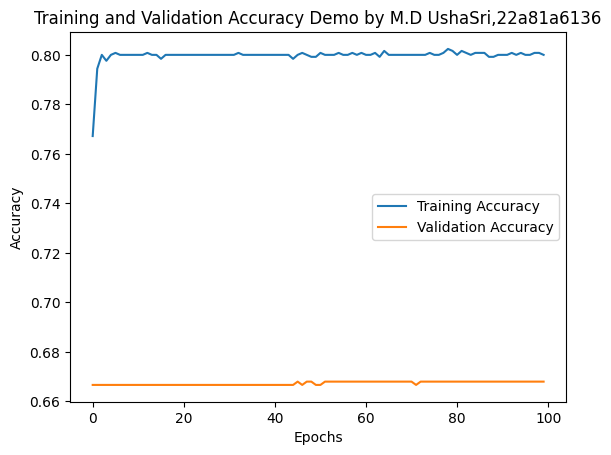

In [9]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Demo by M.D UshaSri,22a81a6136')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


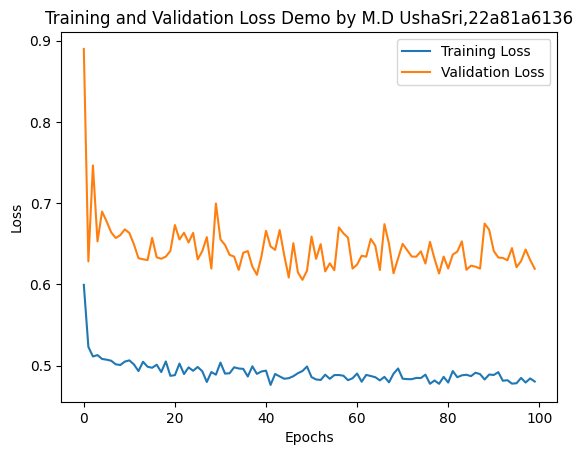

In [10]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Demo by M.D UshaSri,22a81a6136')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step
Confusion Matrix:
[[499   1]
 [250   0]]


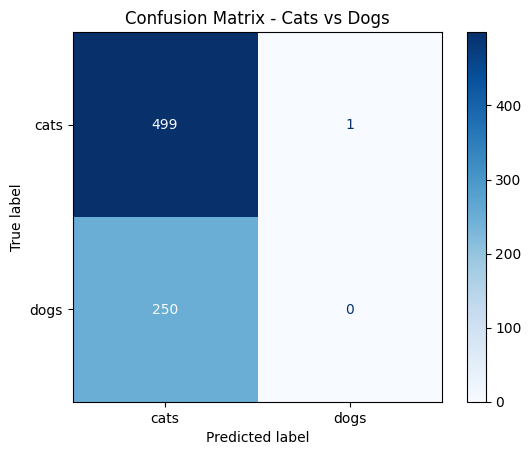

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


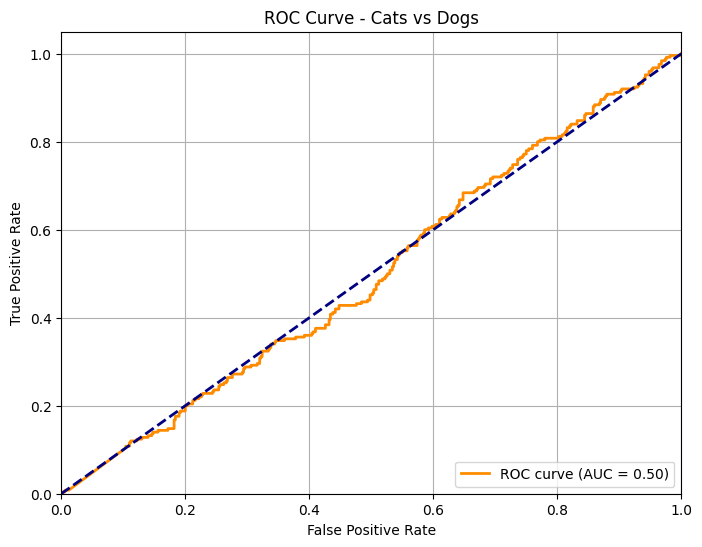

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.67      1.00      0.80       500
        dogs       0.00      0.00      0.00       250

    accuracy                           0.67       750
   macro avg       0.33      0.50      0.40       750
weighted avg       0.44      0.67      0.53       750



In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Step 1: Get true labels and predictions from the validation generator
# Set shuffle=False to maintain order between filenames and labels
validation_generator.reset()  # Important to reset the generator
y_true = validation_generator.classes  # Ground truth labels

# Get model predictions (probabilities)
y_pred_probs = model.predict(validation_generator, verbose=1)

# Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Step 2: Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Step 3: Display the confusion matrix
labels = list(validation_generator.class_indices.keys())  # ['cats', 'dogs']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Cats vs Dogs")
plt.show()


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


validation_generator.reset()

# Get true labels
y_true = validation_generator.classes

# Get predicted probabilities for the positive class (dogs)
y_pred_probs = model.predict(validation_generator, verbose=1).flatten()

# Compute False Positive Rate, True Positive Rate and thresholds
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Cats vs Dogs')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


from sklearn.metrics import classification_report

# Reset the validation generator to ensure proper label alignment
validation_generator.reset()

# True labels
y_true = validation_generator.classes

# Predicted probabilities
y_pred_probs = model.predict(validation_generator, verbose=1).flatten()

# Convert probabilities to binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

# Get class labels
class_labels = list(validation_generator.class_indices.keys())  # ['cats', 'dogs']

# Generate and print the classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:")
print(report)